In [65]:
import numpy as np
import matplotlib.pyplot as plt
import h5py as h5
import sys
from tqdm import tqdm 

# set cosmology (for mdpl2)
from colossus.cosmology import cosmology
cosmo = cosmology.setCosmology('planck13')
a = 0.83760
redshift=1/a-1
H = cosmo.Hz(redshift)
h = cosmo.h

import halotools.sim_manager as sim_manager
import halotools.mock_observables as mock_observables

from compact.velocities.pw_moments import *
from compact.velocities.moments import *
from compact.streaming import *
from compact.tpcf import *
from compact.plot import *
from compact.model import *

from scipy.interpolate import UnivariateSpline

# reload project when changes are made
%load_ext autoreload
%autoreload 2

# plotting config
import matplotlib
matplotlib.rcParams.update({'text.usetex': True, 
                            'font.family': 'Computer Modern Roman'})
plt.rcParams['axes.labelsize'] = 20

import warnings
warnings.filterwarnings('ignore')

import psutil
psutil.Process().nice(10)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [155]:
# define grids

r_perp = np.linspace(5, 140, 135+1)
r_los = np.linspace(5, 140, 135+1)

r_p = 0.5*(r_perp[1:]+r_perp[:-1])
r_l = 0.5*(r_los[1:]+r_los[:-1])


r_p_2d, r_l_2d = np.meshgrid(r_p, r_l, indexing='ij')
r = np.sqrt(r_p_2d**2 + r_l_2d**2)

mu = r_p_2d/r 

x = r * ( 1 - mu ) 
x2 = r - r_p

In [3]:
import os

def bin_pairwise_cat(raw_file_path, save_dir, R_bins, rlos_bins, M_bins):
    """
    Reads HDF5 galaxy catalog data, bins it by R and rlos, and saves the result.
    
    Parameters:
    - raw_file_path: str, path to the raw hdf5 file
    - save_dir: str, directory where the binned data should be saved
    - R_bins: array-like, the bin edges for R
    - rlos_bins: array-like, the bin edges for rlos
    
    Returns:
    - binned_dict: A nested dictionary structured as dict[R_bin_idx][rlos_bin_idx]['vpeclos']
    - master_df: The full Pandas DataFrame for advanced querying.
    """
    Mcens = (M_bins[:, 0]*M_bins[:, 1])**0.5  

    all_dfs = []
    
    # 1. Read and compile all data into a single DataFrame
    with h5.File(raw_file_path, 'r') as hdf:
        for k in range(len(Mcens)):
            # Load data for mass bin 'k'
            df = pd.DataFrame({
                'R': hdf[f'R/{k}'][()],
                'rlos': hdf[f'rlos/{k}'][()],
                'vpeclos': hdf[f'vpeclos/{k}'][()],
                'vr': hdf[f'vr/{k}'][()],
                'vphyslos': hdf[f'vphyslos/{k}'][()],
                'Mvir': Mcens[k]*np.ones(len(hdf[f'R/{k}'][()])) # assign same mass to all
            })

        
            # 2. Apply binning using pd.cut
            # labels=False returns integer indices for the bins
            df['M_bin'] = k #pd.cut(df['Mvir'], bins=M_bins, labels=False, include_lowest=True)
            df['R_bin'] = pd.cut(df['R'], bins=R_bins, labels=False, include_lowest=True)
            df['rlos_bin'] = pd.cut(df['rlos'], bins=rlos_bins, labels=False, include_lowest=True)
            
            # Drop data points that fall completely outside your defined bin edges
            df = df.dropna(subset=['M_bin', 'R_bin', 'rlos_bin']).copy()
            
            # Convert bin labels to integers
            df['M_bin'] = df['M_bin'].astype(int)
            df['R_bin'] = df['R_bin'].astype(int)
            df['rlos_bin'] = df['rlos_bin'].astype(int)
            
            all_dfs.append(df)
            
    # Combine everything
    master_df = pd.concat(all_dfs, ignore_index=True)
    
    # 3. Generate an indicative filename based on the bin inputs
    # Format: binned_R[len]_[min]-[max]_rlos[len]_[min]-[max].h5
    filename = (
        f"binned_"
        f"M{len(M_bins)-1}_{M_bins[0, 0]:.2e}-{M_bins[-1, -1]:.2e}_" 
        f"R{len(R_bins)-1}_{R_bins[0]:.1f}-{R_bins[-1]:.1f}_"
        f"rlos{len(rlos_bins)-1}_{rlos_bins[0]:.1f}-{rlos_bins[-1]:.1f}.h5"
    )
    save_path = os.path.join(save_dir, filename)
    
    # 4. Save the DataFrame to disk for easy retrieval later
    # Format 'table' allows for fast querying directly from the hard drive later if needed
    master_df.to_hdf(save_path, key='binned_data', mode='w', format='table')
    print(f"Successfully saved binned data to: {save_path}")
    
    # 5. Build a nested dictionary for immediate in-script analysis
    binned_dict = {}
    
    # Pandas groupby handles the 3D separation (R, rlos) in one fast sweep
    for (k, r_i, rlos_i), group in master_df.groupby(['M_bin', 'R_bin', 'rlos_bin']):
        if k not in binned_dict:
            binned_dict[k] = {}
        if r_i not in binned_dict[k]:
            binned_dict[k][r_i] = {}
            
        binned_dict[k][r_i][rlos_i] = {
            'vpeclos': group['vpeclos'].values,
            'vr': group['vr'].values,
            'vphyslos': group['vphyslos'].values,
            'rlos': group['rlos'].values,
            'R': group['R'].values,
            'Mvir': group['Mvir'].values
        }
        
    return binned_dict, master_df


def load_pairwise_cat(file_path):
    """
    Loads binned HDF5 pair catalog data saved by bin_pairwise_cat.
    
    Parameters:
    - file_path: str, the exact path to the saved .h5 file
    
    Returns:
    - binned_dict: The reconstructed nested dictionary dict[R_bin_idx][rlos_bin_idx]
    - master_df: The full loaded Pandas DataFrame
    """
    # 1. Load the master DataFrame using the key we defined during saving
    master_df = pd.read_hdf(file_path, key='binned_data')
    
    # 2. Reconstruct the nested dictionary using the exact same groupby logic
    binned_dict = {}
    
    for (k, r_i, rlos_i), group in master_df.groupby(['M_bin', 'R_bin', 'rlos_bin']):
        if k not in binned_dict:
            binned_dict[k] = {}
        if r_i not in binned_dict[k]:
            binned_dict[k][r_i] = {}
            
        binned_dict[k][r_i][rlos_i] = {
            'vpeclos': group['vpeclos'].values,
            'vphyslos': group['vphyslos'].values,
            'vr': group['vr'].values,
            'rlos': group['rlos'].values,
            'R': group['R'].values,
            'Mvir': group['Mvir'].values
        }
        
    return binned_dict, master_df

In [ ]:
# define paths to selections, save

cosmo_nums = np.array([1992, 1994, 1927, 1986, 1852])

paths = [f'/spiffball/cosweeney/simulations/Quijote/halos/{sim_num}/data/pairwise_velocity_selections/halo_halo_pairs_no_vlos_cut_1e13_mass_cut_SB250.hdf5' for sim_num in cosmo_nums]
save_paths = [f'/spiffball/cosweeney/simulations/Quijote/halos/{sim_num}/data/' for sim_num in cosmo_nums]

# bin selections

# mass bins
dex_width = 0.1  # bin width in log10(mass); narrower = 0.1, wider = 0.3
log_edges = np.arange(np.log10(1e13), np.log10(1e15) + dex_width, dex_width)
massbins = np.column_stack([10**log_edges[:-1], 10**log_edges[1:]])[::6] # select 4 bins from the full set of mass bins

M_cens = (massbins[:, 0]*massbins[:, 1])**0.5

binned_dicts = []
master_dfs = []

for p_i, path in enumerate(paths):
    binned_dict, master_df = bin_pairwise_cat(path, save_paths[p_i], R_bins=r_perp, rlos_bins=r_los, M_bins=massbins)
    
    binned_dicts.append(binned_dict)
    master_dfs.append(master_df)

Successfully saved binned data to: /spiffball/cosweeney/simulations/Quijote/halos/1992/data/binned_M3_1.00e+13-7.94e+14_R135_5.0-140.0_rlos135_5.0-140.0.h5
Successfully saved binned data to: /spiffball/cosweeney/simulations/Quijote/halos/1994/data/binned_M3_1.00e+13-7.94e+14_R135_5.0-140.0_rlos135_5.0-140.0.h5
Successfully saved binned data to: /spiffball/cosweeney/simulations/Quijote/halos/1927/data/binned_M3_1.00e+13-7.94e+14_R135_5.0-140.0_rlos135_5.0-140.0.h5


In [27]:

with h5.File(paths[3], 'r') as hdf:
    # print(hdf['r'].keys())
    print((M_cens[0]*np.ones(len(hdf[f'R/{0}'][()]))).shape)

(6026918188,)


In [5]:
# load saved binned data

cosmo_nums = np.array([1992, 1994, 1927, 1986, 1852])

save_paths = [f'/spiffball/cosweeney/simulations/Quijote/halos/{sim_num}/data/' for sim_num in cosmo_nums]

# bin selections

# mass bins
dex_width = 0.1  # bin width in log10(mass); narrower = 0.1, wider = 0.3
log_edges = np.arange(np.log10(1e13), np.log10(1e15) + dex_width, dex_width)
massbins = np.column_stack([10**log_edges[:-1], 10**log_edges[1:]])[::6] # select 4 bins from the full set of mass bins

M_cens = (massbins[:, 0]*massbins[:, 1])**0.5

binned_dicts = []
master_dfs = []

for p_i, path in enumerate(save_paths[:3]):
    binned_dict, master_df = load_pairwise_cat(path+'binned_M3_1.00e+13-7.94e+14_R135_5.0-140.0_rlos135_5.0-140.0.h5')
    
    binned_dicts.append(binned_dict)
    master_dfs.append(master_df)

In [78]:
# compute mean radial velocity profiles <v_r|r, M> for each sim 

mean_vr_r_m_sims = np.full((len(cosmo_nums[:3]), len(M_cens), len(r_p)), np.nan)
mean_vr_r_m_sims_interps = np.empty((len(cosmo_nums[:3]), len(M_cens)), dtype=object)

for sim in range(len(cosmo_nums[:3])):
    data_df = master_dfs[sim]

    data_df['r'] = np.sqrt(data_df['R']**2 + data_df['rlos']**2)
    data_df['r_bin'] = pd.cut(data_df['r'], bins=r_perp, labels=False, include_lowest=True)

    profile = (
        data_df.dropna(subset=['r_bin'])
        .groupby(['M_bin', 'r_bin'])['vr']
        .mean()
    )

    mean_vr_r_m = profile.unstack('r_bin').reindex(columns=range(len(r_p))).values

    mean_vr_r_m_sims[sim, :mean_vr_r_m.shape[0]] = mean_vr_r_m

    for k in range(mean_vr_r_m.shape[0]):
        y = mean_vr_r_m[k]
        mask = np.isfinite(y)
        if mask.sum() < 4:  # need enough points for k=5 spline; adjust threshold if needed
            mean_vr_r_m_sims_interps[sim, k] = None
            continue
        mean_vr_r_m_sims_interps[sim, k] = UnivariateSpline(r_p[mask], y[mask], s=0, k=5, ext=3)

In [79]:
# save 
save_path = '/spiffball/cosweeney/simulations/Quijote/halos/data/mean_vr_r_m_sims.hdf5'

with h5.File(save_path, 'w') as hdf:
    hdf.create_dataset('mean_vr_r_m_sims', data=mean_vr_r_m_sims)
    #hdf.create_dataset('interps', data=mean_vr_r_m_sims_interps) 

    hdf.attrs['r_edges'] = r_perp
    hdf.attrs['M_edges'] = massbins

In [85]:
# fit skew-t to P(v_pec|R, rlos, M) to each sim

from scipy.optimize import curve_fit

nus = 6

ST_pars = np.full((len(cosmo_nums[:3]), len(M_cens), len(r_p), len(r_l), 3), np.nan)
ST_errs = np.full(ST_pars.shape, np.nan)

for sim in range(len(cosmo_nums[:3])):
    data_dict = binned_dicts[sim]
    for k in range(len(M_cens)):
        if k not in data_dict:
            continue  # empty mass bin — leave as nan

        mean_vr_interp = mean_vr_r_m_sims_interps[sim][k]

        for j in range(len(r_p)):
            if j not in data_dict[k]:
                continue

            for i in range(len(r_l)):
                if i not in data_dict[k][j]:
                    continue

                r_3d = np.sqrt(r_p[j]**2 + r_l[i]**2)
                theta = np.arctan2(r_l[i], r_p[j])
                sin = np.sin(theta)

                peak = mean_vr_interp(r_3d) * sin

                width = np.std(data_dict[k][j][i]['vpeclos'])

                ve = np.linspace(peak-2500, peak+2500, 50+1)
                vc = 0.5*(ve[1:] + ve[:-1])

                hist, edges = np.histogram(data_dict[k][j][i]['vpeclos'], bins=ve, density=True)
                cent = 0.5*(edges[1:] + edges[:-1])

                if np.isnan(hist).any():
                    continue

                try:
                    p, c = curve_fit(lambda x, xi, omega, alpha: skewed_t_pdf(x, xi=xi, omega=omega, alpha=alpha, nu=nus),
                                  cent, hist, p0=[peak, width, -0.1], method='lm', maxfev=5_000)
                except RuntimeError:
                    continue
                
                ST_pars[sim, k, j, i] = p
                ST_errs[sim, k, j, i] = np.sqrt(np.diag(c))
                


In [74]:
n_total = n_no_mass = n_no_R = n_no_rlos = n_nan_hist = n_fit = 0

for sim in range(len(cosmo_nums[:3])):
    data_dict = binned_dicts[sim]
    for k in range(len(M_cens)):
        if k not in data_dict:
            n_no_mass += 1
            continue
        mean_vr_interp = mean_vr_r_m_sims_interps[sim][k]
        for j in range(len(r_p)):
            if j not in data_dict[k]:
                n_no_R += 1
                continue
            for i in range(len(r_l)):
                n_total += 1
                if i not in data_dict[k][j]:
                    n_no_rlos += 1
                    continue

                r_3d = np.sqrt(r_p[j]**2 + r_l[i]**2)
                theta = np.arctan2(r_l[i], r_p[j])
                peak = mean_vr_interp(r_3d) * np.sin(theta)
                width = np.std(data_dict[k][j][i]['vpeclos'])
                ve = np.linspace(peak-2500, peak+2500, 51)
                hist, edges = np.histogram(data_dict[k][j][i]['vpeclos'], bins=ve, density=True)
                cent = 0.5*(edges[1:] + edges[:-1])

                if np.isnan(hist).any():
                    n_nan_hist += 1
                    continue

                p, c = curve_fit(lambda x, xi, omega, alpha: skewed_t_pdf(x, xi=xi, omega=omega, alpha=alpha, nu=nus),
                                  cent, hist, p0=[peak, width, -0.1], method='lm', maxfev=5_000)
                ST_pars[sim, k, j, i] = p
                ST_errs[sim, k, j, i] = np.sqrt(np.diag(c))
                n_fit += 1

print(f"total={n_total}, no_mass={n_no_mass}, no_R={n_no_R}, no_rlos={n_no_rlos}, nan_hist={n_nan_hist}, fit={n_fit}")

total=200475, no_mass=1, no_R=0, no_rlos=3974, nan_hist=196501, fit=0


In [87]:
np.isnan(ST_pars[:, :, :, :, 1]).sum()/len(ST_pars[:, :, :, :, 1].flatten())

np.float64(0.1091952446273434)

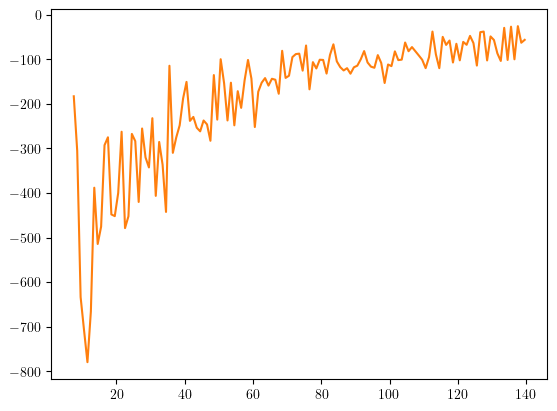

In [77]:
plt.plot(r_p, mean_vr_interp(r_p))
plt.plot(r_p, mean_vr_r_m_sims[sim][k])

In [39]:
print(sim, k, j, i)

0 2 0 4


In [35]:
len(data_dict[k][j])

39

In [36]:
len(data_dict[0][0])

135

In [88]:
# save 
save_path = '/spiffball/cosweeney/simulations/Quijote/halos/data/ST_pars_nu6.hdf5'

with h5.File(save_path, 'w') as hdf:
    hdf.create_dataset('STpars', data=ST_pars)
    hdf.create_dataset('ST_errs', data=ST_errs)

    hdf.attrs['rperp_edges'] = r_perp
    hdf.attrs['rlos_edges'] = r_los
    hdf.attrs['M_edges'] = massbins
    hdf.attrs['nu'] = nus
    hdf.attrs['sim_sums'] = cosmo_nums[:3] # only doing a subset first

In [89]:
def sigma_mod(x, sigma0, A_rho, sigma_rho):
    return np.sqrt(2 * sigma0**2 * (1 - A_rho * np.exp(-x / sigma_rho)))

def delta_mod(x, A_delta, sigma_delta):
    return A_delta * x / (sigma_delta + x)

In [43]:
# measure widths
meas_sigv = np.full((len(cosmo_nums[:3]), len(M_cens), len(r_p), len(r_l)), np.nan)

for sim in range(len(cosmo_nums[:3])):
    data_dict = binned_dicts[sim]
    for k in range(len(M_cens)):

        if k not in data_dict:
            continue  # empty mass bin — leave as nan

        for j in range(len(r_p)):
            if j not in data_dict[k]:
                continue

            for i in range(len(r_l)):
                if i not in data_dict[k][j]:
                    continue
                
                std = np.std(data_dict[k][j][i]['vpeclos'])

                meas_sigv[sim, k, j, i] = std

In [46]:
available_sim_nums = np.array([                                                    # only this subset of the 2000 sims are available on spiffball
    1402, 1655, 1740, 1791, 1807, 1820, 1839, 1861, 1889, 1902, 1911, 1915, 1923,
    1930, 1936, 1945, 1952, 1962, 1966, 1974, 1979, 1984, 1988, 1992, 1996,
    1625, 1656, 1757, 1793, 1810, 1824, 1852, 1871, 1894, 1906, 1912, 1916, 1927,
    1933, 1937, 1948, 1955, 1963, 1967, 1975, 1980, 1985, 1989, 1993, 1997,
    1630, 1659, 1764, 1795, 1818, 1826, 1857, 1877, 1897, 1907, 1913, 1919, 1928,
    1934, 1943, 1949, 1956, 1964, 1970, 1976, 1982, 1986, 1990, 1994, 1998,
    1640, 1704, 1769, 1797, 1819, 1835, 1859, 1887, 1898, 1909, 1914, 1921, 1929,
    1935, 1944, 1950, 1960, 1965, 1972, 1977, 1983, 1987, 1991, 1995, 590,
])

sim_nums = [i for i in range(2_000)] # all cosmologies

q_cosmos = np.zeros((len(sim_nums), 5))

for num in sim_nums:
    dat_path = f'/spiffball/edgarmsc/simulations/Quijote/Snapshots/latin_hypercube_HR_cosmo/Cosmo_params_{num}.dat'

    df = pd.read_csv(dat_path, sep=r'\s+', header=None, names=['Om', 'Ob', 'h', 'ns', 's8'])

    q_cosmos[num] = df.values[0]

LH_cosmos = q_cosmos[cosmo_nums]

col_cosmos = []

for i in range(len(cosmo_nums)):

    sim_num = cosmo_nums[i]
    sim_cosmo = LH_cosmos[i]

    params = {'flat': True, 'H0': 100 * sim_cosmo[2], 'Om0': sim_cosmo[0], 'Ob0': sim_cosmo[1], 'sigma8': sim_cosmo[4], 'ns': sim_cosmo[3]}

    cosmo = cosmology.setCosmology('myCosmo', params)

    col_cosmos.append(cosmo)

In [105]:
LH_cosmos

array([[0.1499 , 0.03475, 0.8141 , 1.1023 , 0.6011 ],
       [0.2927 , 0.04833, 0.5623 , 0.8073 , 0.8415 ],
       [0.1881 , 0.06873, 0.6485 , 1.0081 , 0.6871 ],
       [0.4977 , 0.05655, 0.6983 , 1.1879 , 0.8765 ],
       [0.3775 , 0.03797, 0.8971 , 0.8891 , 0.9479 ]])

In [47]:
# compute 1-D isotropic halo velocity dispersion for halos in sims. How different from one another, MDPL2?

# non-linear Pk instead 
import camb
from camb import model

camb_params = [[col_cosmos[i].H0, col_cosmos[i].Ombh2, col_cosmos[i].Omh2 - col_cosmos[i].Ombh2, col_cosmos[i].ns] for i in range(len(col_cosmos))]

def get_sigma0_nl(params, redshift, kmax=10.0, npoints=500):

    pars = camb.set_params(H0=params[0], ombh2=params[1], omch2=params[2], ns=params[3])
    pars.set_matter_power(redshifts=[redshift], kmax=10.0) 
    pars.NonLinear = model.NonLinear_both

    results = camb.get_results(pars)
    kh_nl, z_nl, pk_nl = results.get_matter_power_spectrum(
        minkh=1e-4, maxkh=5.0, npoints=500
    )
    pk_nl = pk_nl[0] 

    h = params[0] / 100.0

    Om0 = (params[1] + params[2]) / h**2
    Omz = Om0 * (1.0 + redshift)**3 / (params[0] / (100.0 * h))**2
    f = Omz**0.55 # growth rate

    a = 1/(1+redshift)
    conv = a * params[0] / h

    sigma0_nl_sq = (f * conv)**2 / (6 * np.pi**2) * simpson(pk_nl, kh_nl)
    sigma0_nl = np.sqrt(sigma0_nl_sq)

    return sigma0_nl


sigma0s = np.zeros(len(cosmo_nums))

for i, cosmo in enumerate(camb_params):
    
    sigma = get_sigma0_nl(cosmo, 0.0)
    print(sigma)

    sigma0s[i] = sigma

204.4450702131158
282.1202981833977
166.31751470001018
585.8636769841737
572.8375498422764


In [98]:
2*204**2

83232

In [57]:
smask.shape

(135, 135)

In [68]:
Delta.flatten()#[dmask]

array([nan, nan, nan, ..., nan, nan, nan])

In [72]:
np.isnan(ST_pars[:, :, :, :, 2]).sum()/len(ST_pars[:, :, :, :, 2].flatten())

np.float64(1.0)

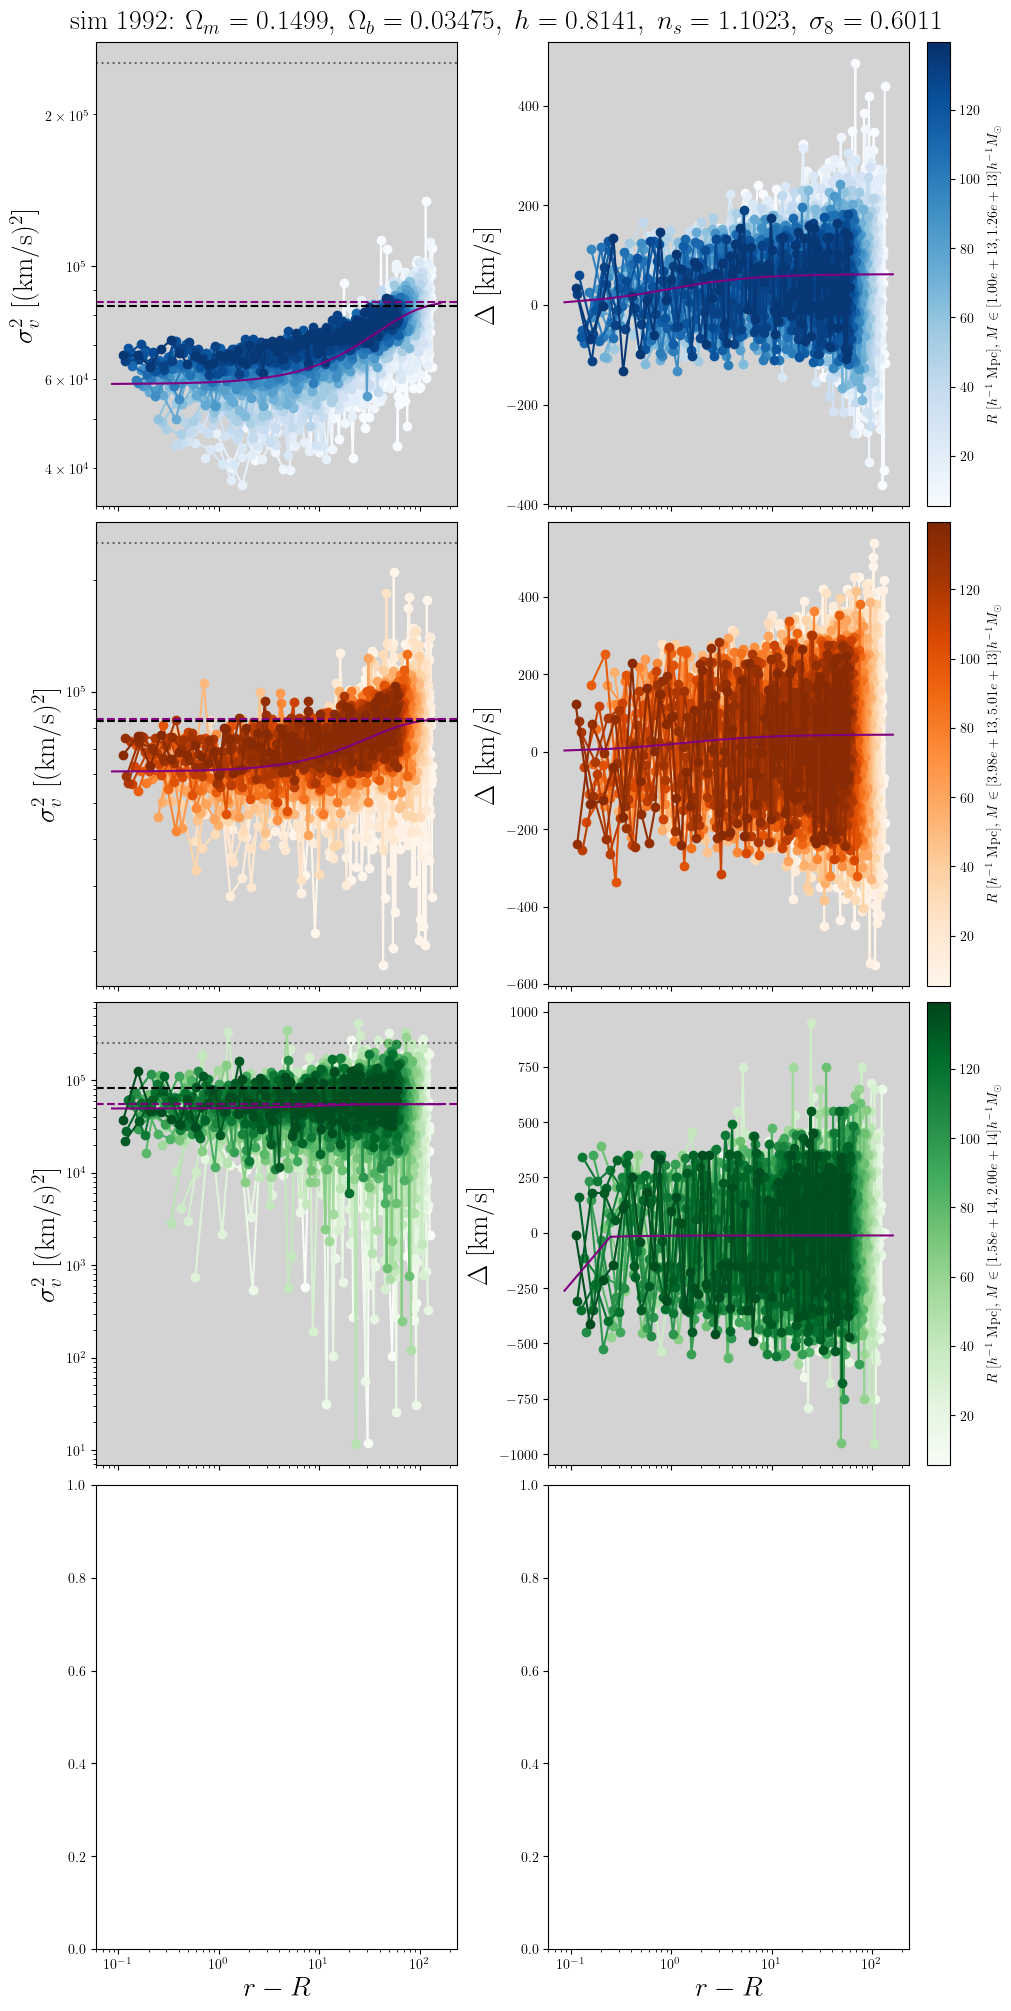

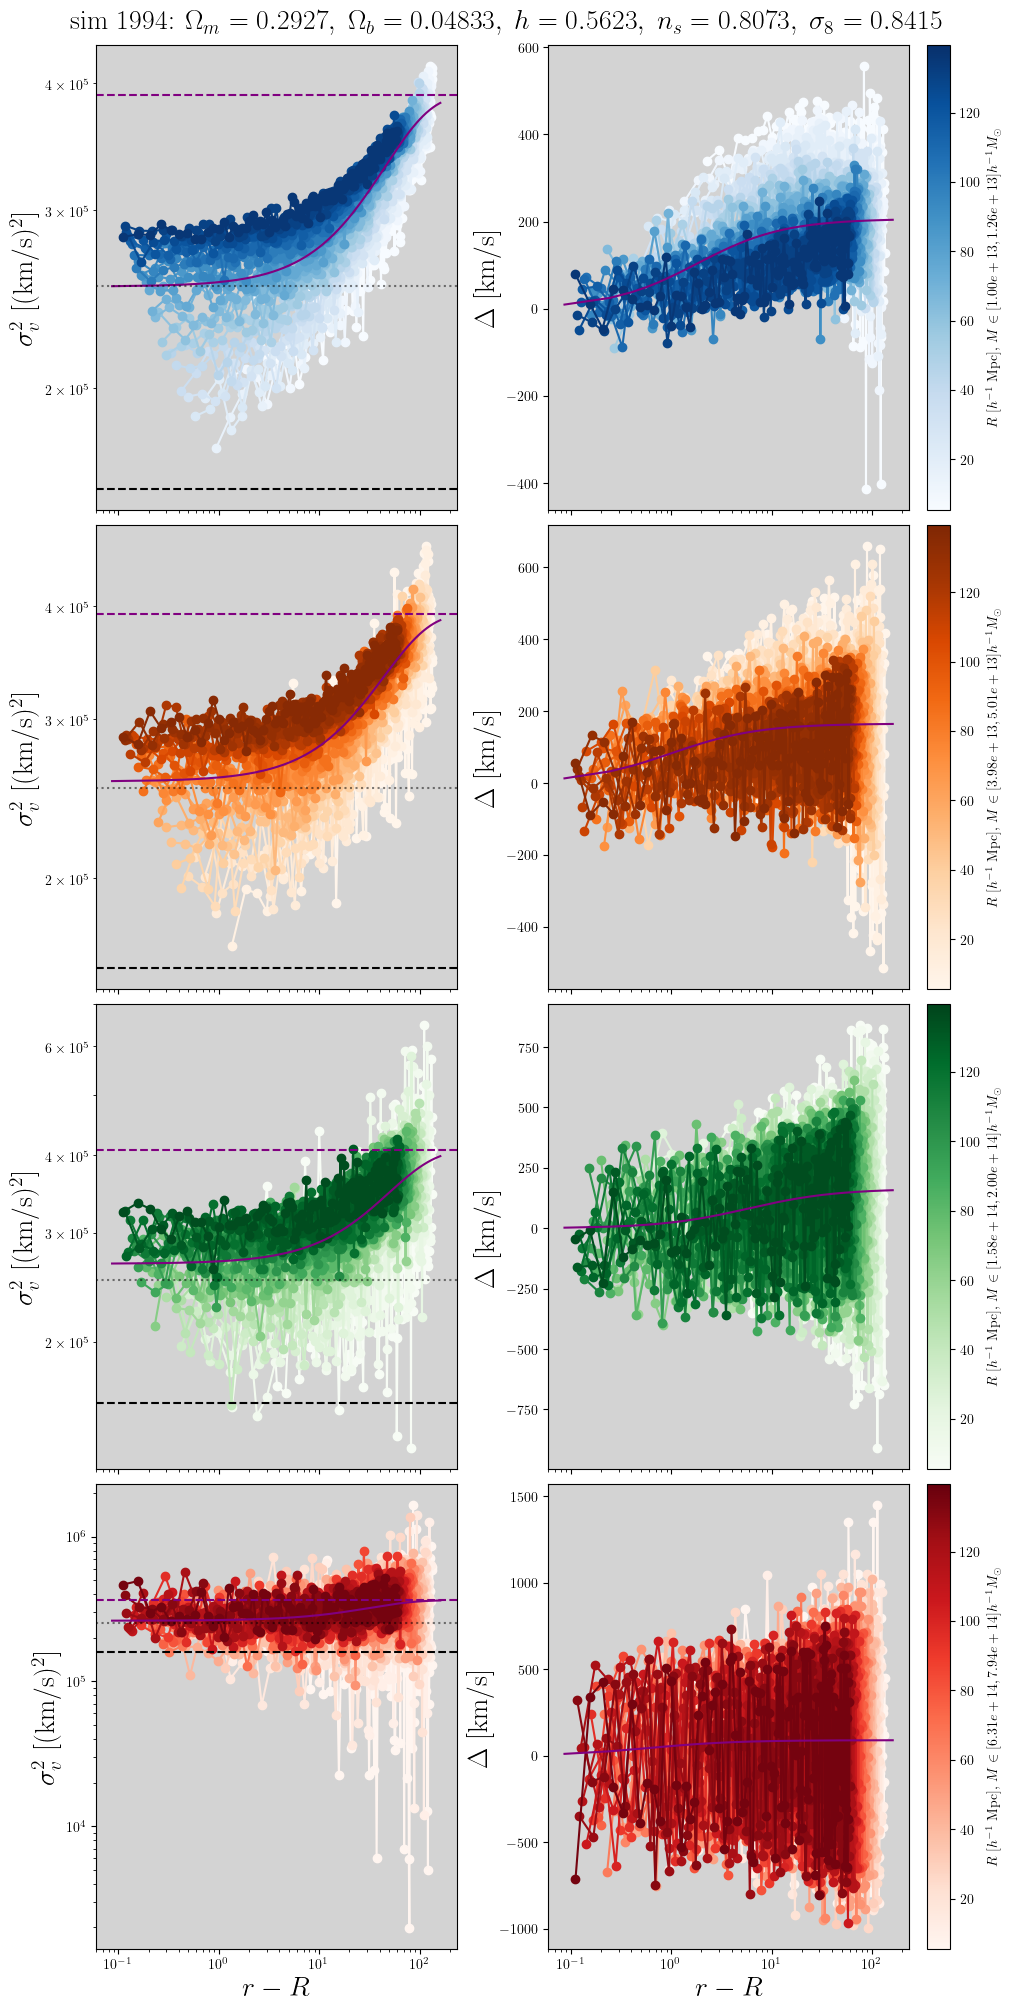

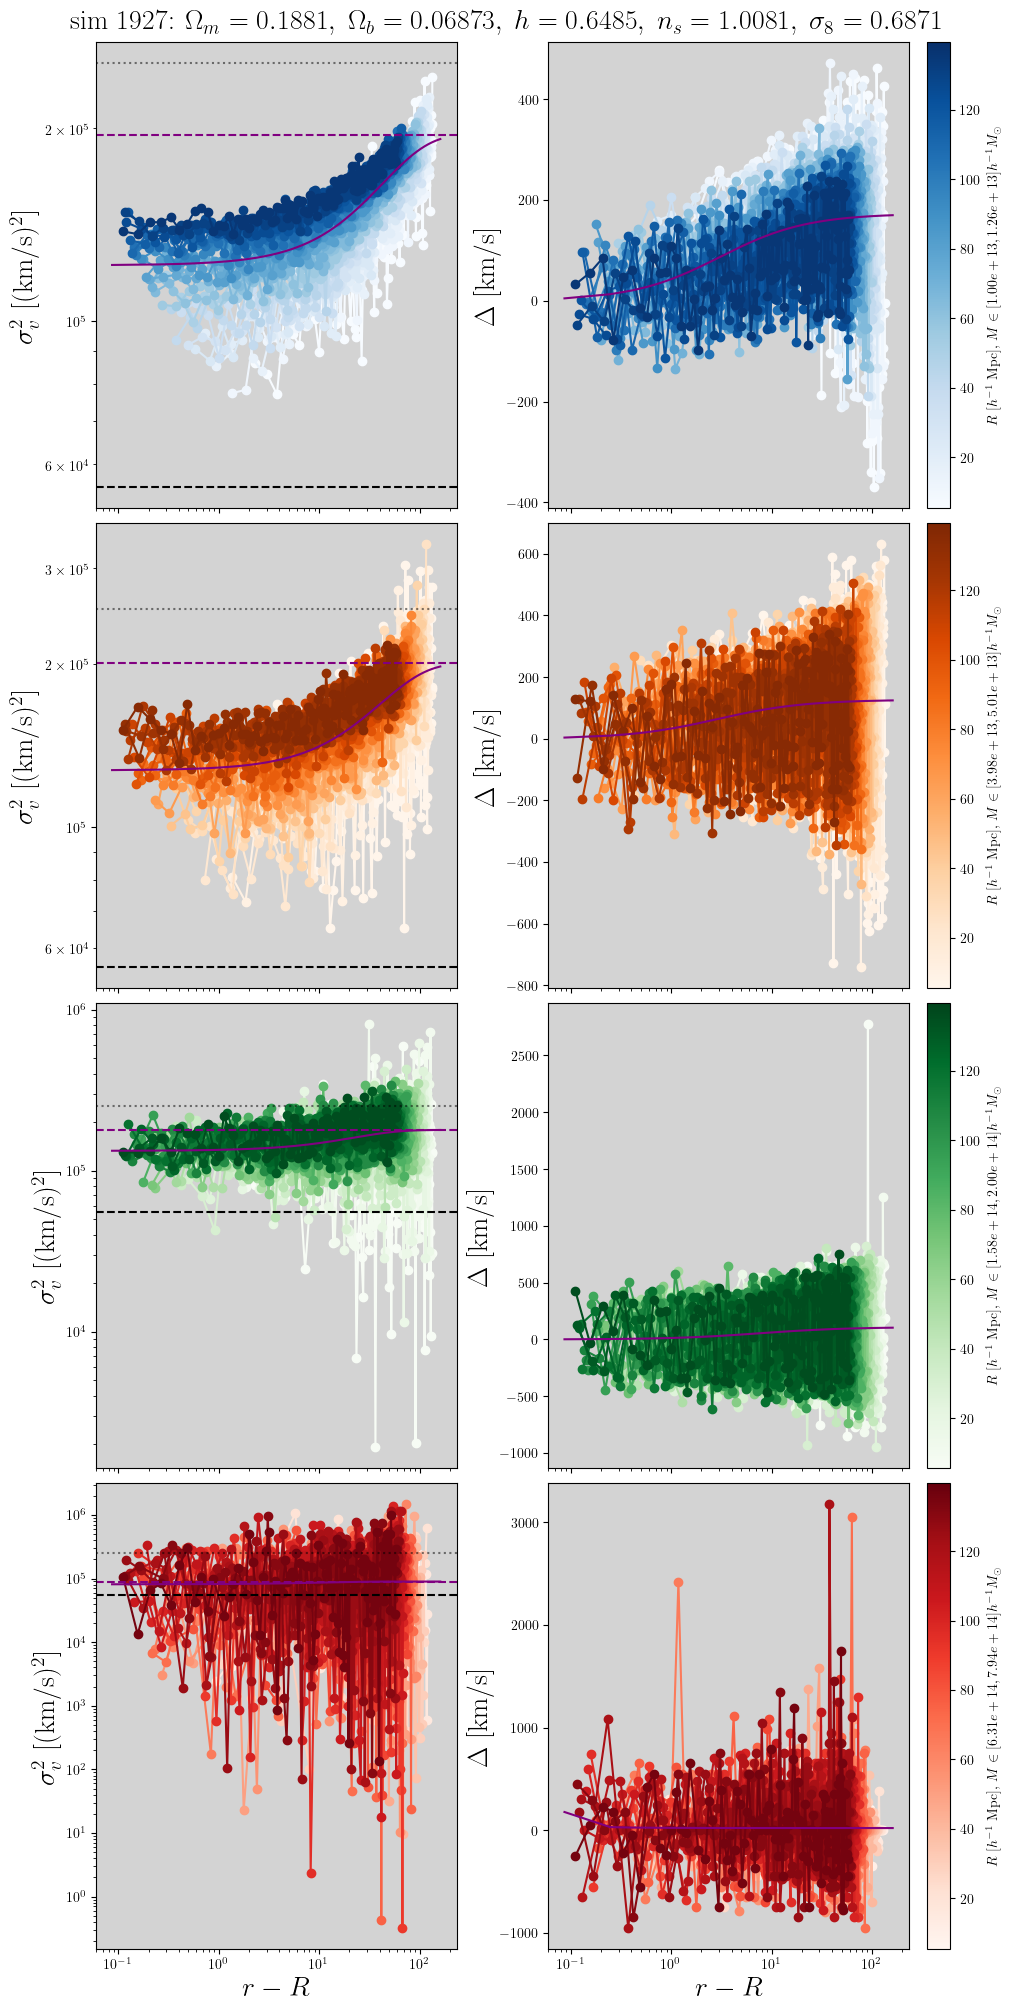

In [159]:
# fit compact functions to \sigma_v, \Delta

from matplotlib.cm import ScalarMappable
from matplotlib.colors import Normalize


colormap_list = [plt.cm.Blues, plt.cm.Oranges, plt.cm.Greens, 
                 plt.cm.Reds, plt.cm.Purples, plt.cm.Greys]

cmaps = [cmap(np.linspace(0, 1, len(r_p))) for cmap in colormap_list]


names = [r'$\sigma_v^2$ [(km/s)$^2$]', r'$\Delta$ [km/s]']

sig_opts = np.full((len(cosmo_nums[:3]), len(M_cens), 3), np.nan)
sig_errs = np.full(sig_opts.shape, np.nan)

del_opts = np.full((len(cosmo_nums[:3]), len(M_cens), 2), np.nan)
del_errs = np.full(del_opts.shape, np.nan)


for sim in range(len(cosmo_nums[:3])):
    fig, ax = plt.subplots(len(M_cens), 2, figsize=(10, 5*len(M_cens)), layout='constrained', sharex=True)

    fig.suptitle(rf"sim {cosmo_nums[sim]}: $\Omega_m={LH_cosmos[sim][0]},\ \Omega_b={LH_cosmos[sim][1]},\ h={LH_cosmos[sim][2]},\ n_s={LH_cosmos[sim][3]},\ \sigma_8={LH_cosmos[sim][4]} $", fontsize=20)

    for k in range(len(M_cens)):
        if sim == 0 and k == 3:
            continue

        mean_vr_interp = mean_vr_r_m_sims_interps[sim][k]

        Delta = ST_pars[sim, k, :, :, 0] - mean_vr_interp(r) * r_l / r
        com_inputs = [meas_sigv[sim, k]**2, Delta]

        smask = np.isfinite(meas_sigv[sim, k].flatten()) & (meas_sigv[sim, k].flatten() > 0.1)
        dmask = np.isfinite(Delta.flatten()) & (Delta.flatten() > -1000)

        # fit models to each input 

        popt_sig, sig_cov = curve_fit(lambda x, sig, A, s: sigma_mod(x, sig, A, s), x.flatten()[smask], (meas_sigv[sim, k]).flatten()[smask], p0=[sigma0s[sim], 0.3, 10], maxfev=5_000, absolute_sigma=False)
        popt_del, del_cov = curve_fit(delta_mod, x.flatten()[dmask], Delta.flatten()[dmask], p0=[100, 1], maxfev=5_000, absolute_sigma=False)

        sig_opts[sim, k] = popt_sig
        sig_errs[sim, k] = np.sqrt(np.diag(sig_cov))
        del_opts[sim, k] = popt_del 
        del_errs[sim, k] = np.sqrt(np.diag(del_cov))

        skip = 5

        xs = np.linspace(x.min()*(1-0.2), x.max()*(1+0.2), 1000)

        for j in range(0, len(r_p), skip):
            for i in range(2):

                y = com_inputs[i][j, :]
                
                if i == 0:
                    mask = y > 0.1
                if i == 1:
                    mask = y > -1000

                ax[k, i].plot(x2[:, j][mask], y[mask], marker='o', c=cmaps[k][j])


                ax[k, i].set_facecolor('lightgray')
                
                ax[k, i].set_ylabel(names[i], fontsize=20)
                
                ax[k, i].set_xscale('log')
                

        norm = Normalize(vmin=min(r_p), vmax=max(r_p))
        sm = ScalarMappable(norm=norm, cmap=colormap_list[k])
        sm.set_array([])  # dummy array
        cbar = fig.colorbar(sm, ax=ax[k, -1])
        cbar.set_label(rf"$R \ [h^{{-1}}$ Mpc], $M\in[{massbins[k, 0]:.2e}, {massbins[k, 1]:.2e}] h^{{-1}} M_\odot $", fontsize=10)

        ax[k, 0].plot(xs, sigma_mod(xs, *popt_sig )**2, c='purple') #*popt_sig
        #ax[k, 0].set_ylim((0.5*(2*sigma0s[sim]**2), 1.5*(2*sigma0s[sim]**2)))
        ax[k, 0].set_xscale('log')
        ax[k, 0].axhline(2*(sigma0s[sim])**2, c='k', ls='--')
        ax[k, 0].axhline(2*(popt_sig[0])**2, c='purple', ls='--')
        ax[k, 0].axhline(2*(355)**2, c='k', ls=':', alpha=0.5)
        ax[k, 0].set_yscale('log')

        ax[-1, 0].set_xlabel(r'$r-R$', fontsize=20)
        ax[-1, 1].set_xlabel(r'$r-R$', fontsize=20)

        ax[k, 1].plot(xs, delta_mod(xs, *popt_del), c='purple')
        #ax[k, 1].set_ylim((-500, 450))


        #ax[0].legend(loc='lower right')


In [113]:
sig_opts.shape

(3, 4, 3)

In [114]:
del_opts.shape

(3, 4, 2)

In [131]:
LH_cosmos[:3, j].shape

(3,)

In [127]:
parameters[:, 0, 0].shape

(3,)

In [139]:
np.concatenate(([355], sig_pars, del_pars)).shape

(5,)

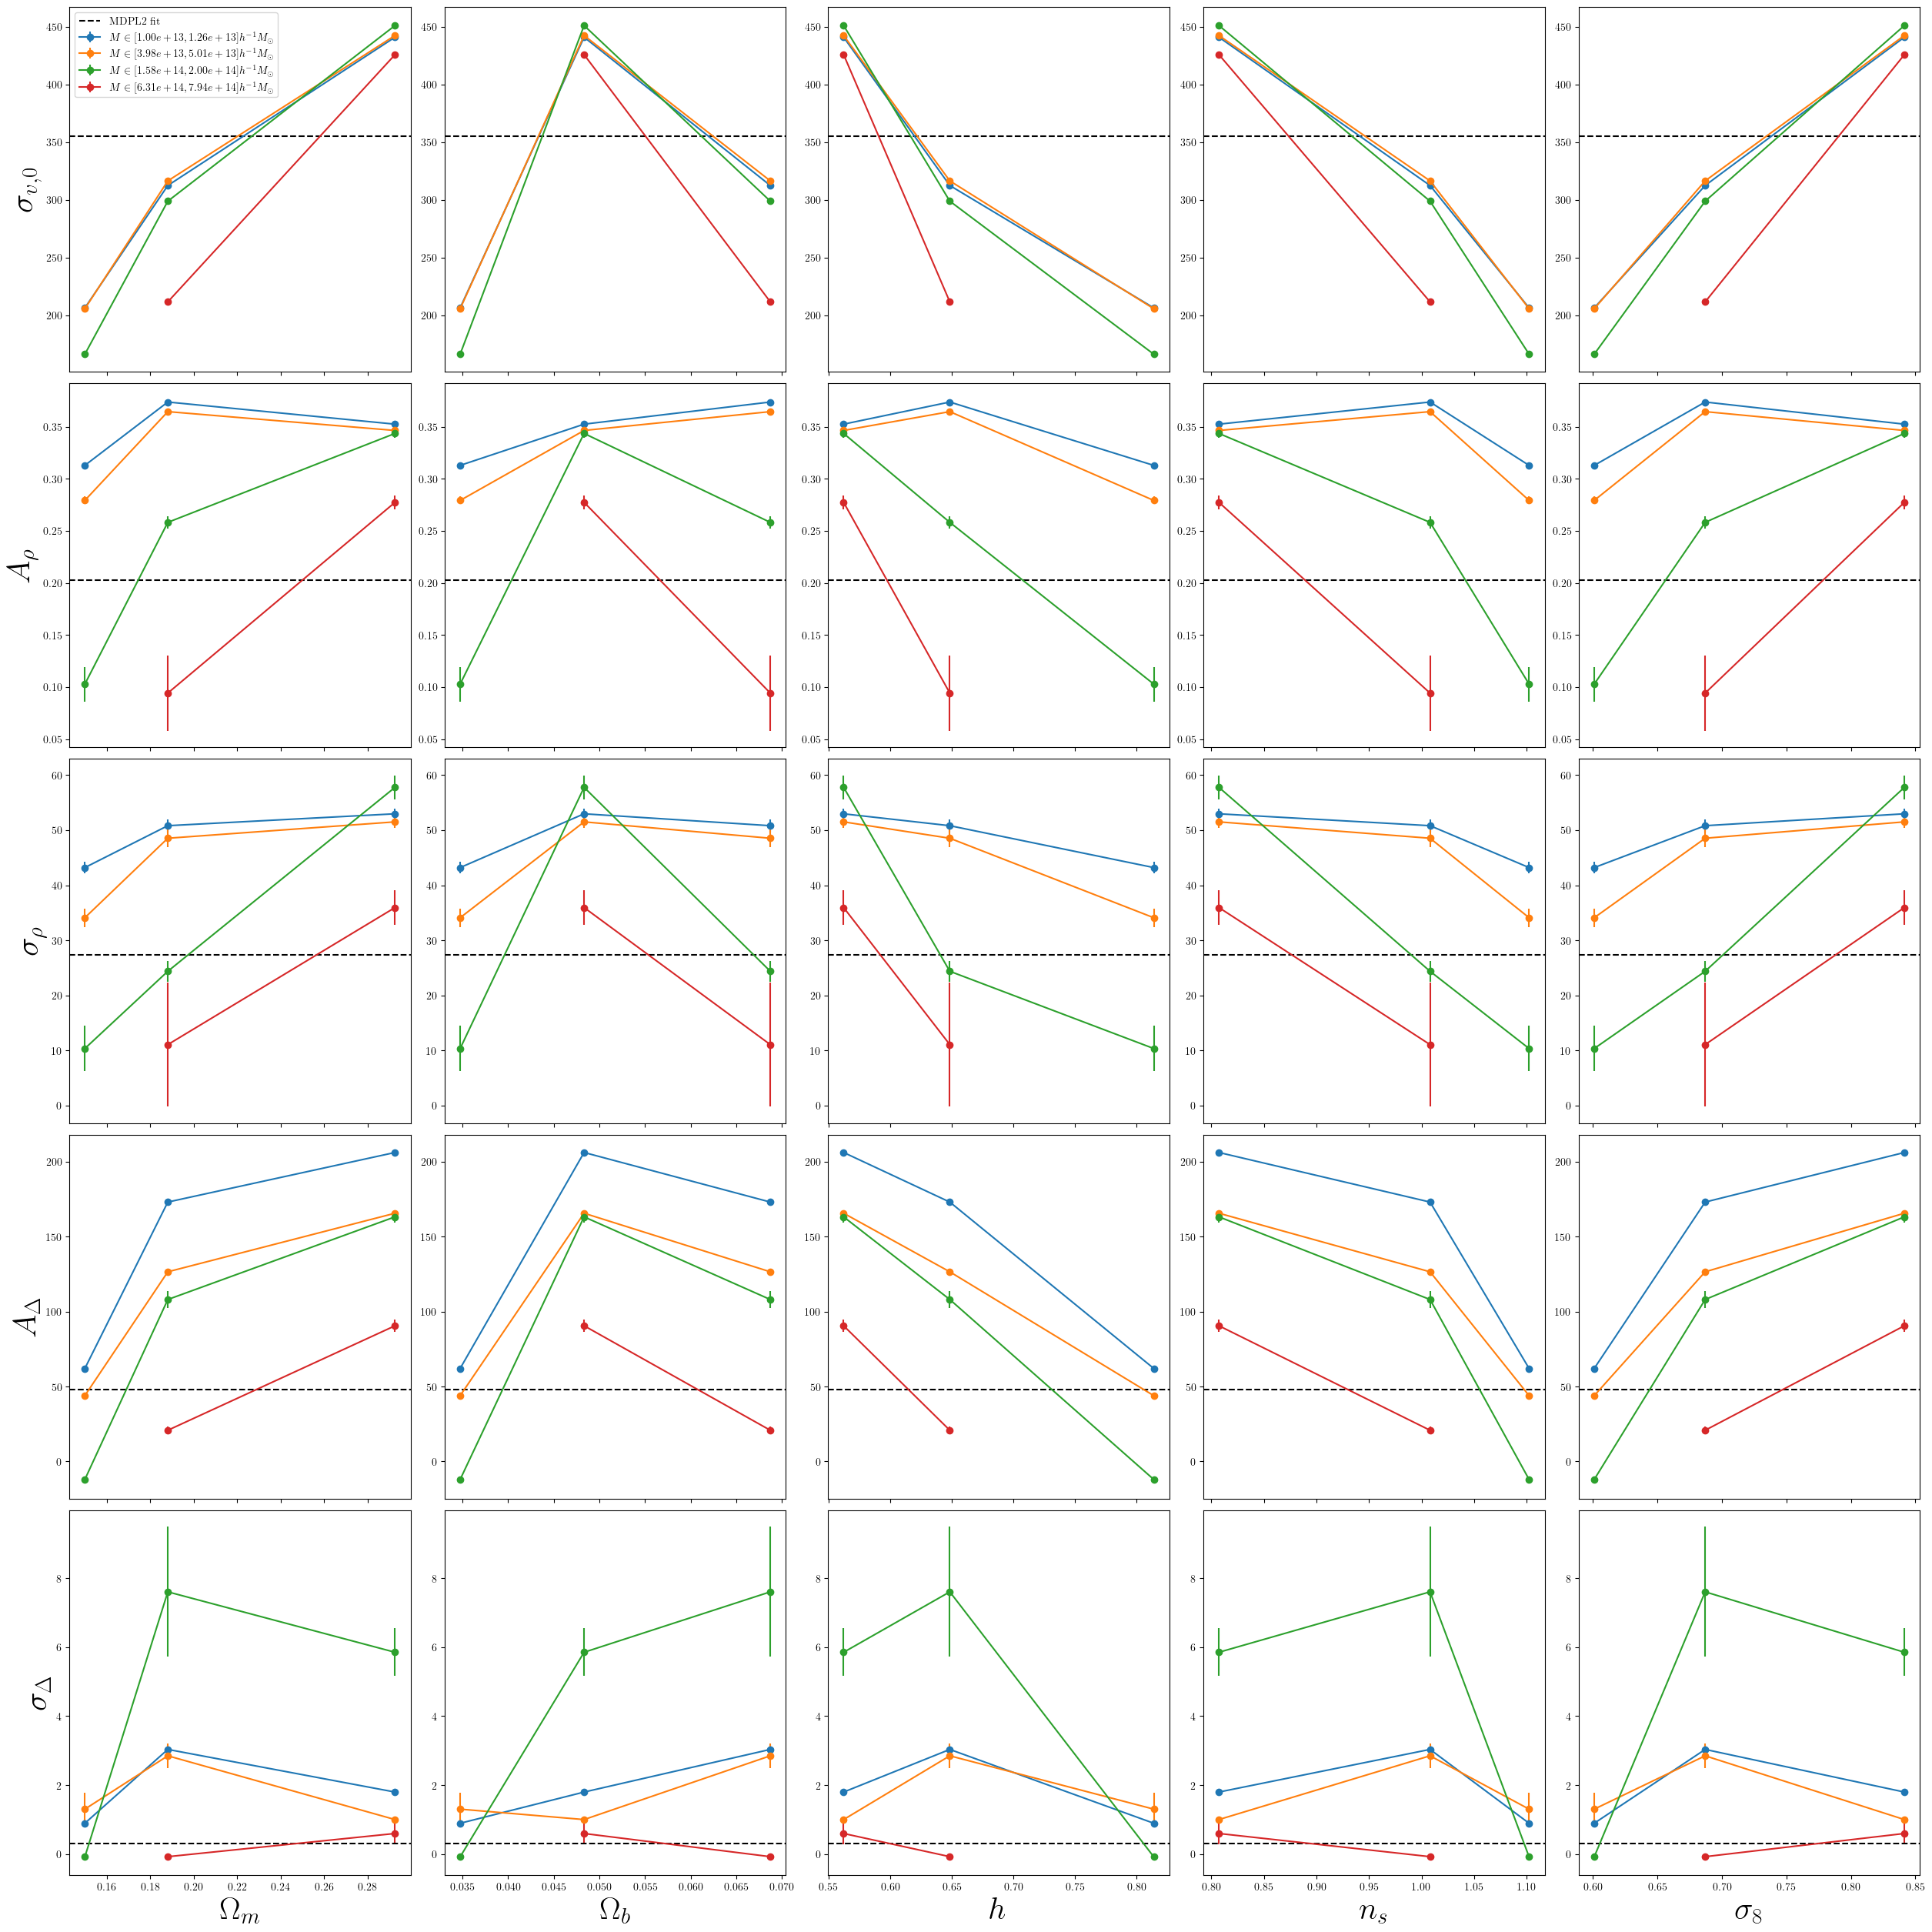

In [158]:
fig, ax = plt.subplots(5, 5, figsize=(25, 25), sharex='col', layout='constrained')

fixed_parameters = np.concatenate(([355], sig_pars, del_pars))
parameters = np.concatenate((sig_opts, del_opts), axis=-1)
errors = np.concatenate((sig_errs, del_errs), axis=-1)

labels = [r"$\sigma_{v, 0}$", r"$A_\rho$", r"$\sigma_\rho$", r"$A_\Delta$", r"$\sigma_\Delta$"]

c_labels = [r"$\Omega_m$", r"$\Omega_b$", r"$h$", r"$n_s$", r"$\sigma_8$"]

for i in range(len(labels)):
    for j in range(len(c_labels)):
        for k in range(len(M_cens)):
            x_plot = LH_cosmos[:3, j]
            order = np.argsort(x_plot)
            ax[i, j].errorbar(x_plot[order], parameters[order, k, i], errors[order, k, i], marker='o', label=f'$M\in[{massbins[k, 0]:.2e}, {massbins[k, 1]:.2e}] h^{{-1}} M_\odot $' if (i == 0 and j == 0) else None)
        
        ax[i, j].axhline(fixed_parameters[i], c='k', ls='--', label=r'MDPL2 fit')
        ax[-1, j].set_xlabel(c_labels[j], fontsize=30)
    ax[i, 0].set_ylabel(labels[i], fontsize=30)

ax[0, 0].legend(fontsize=10)


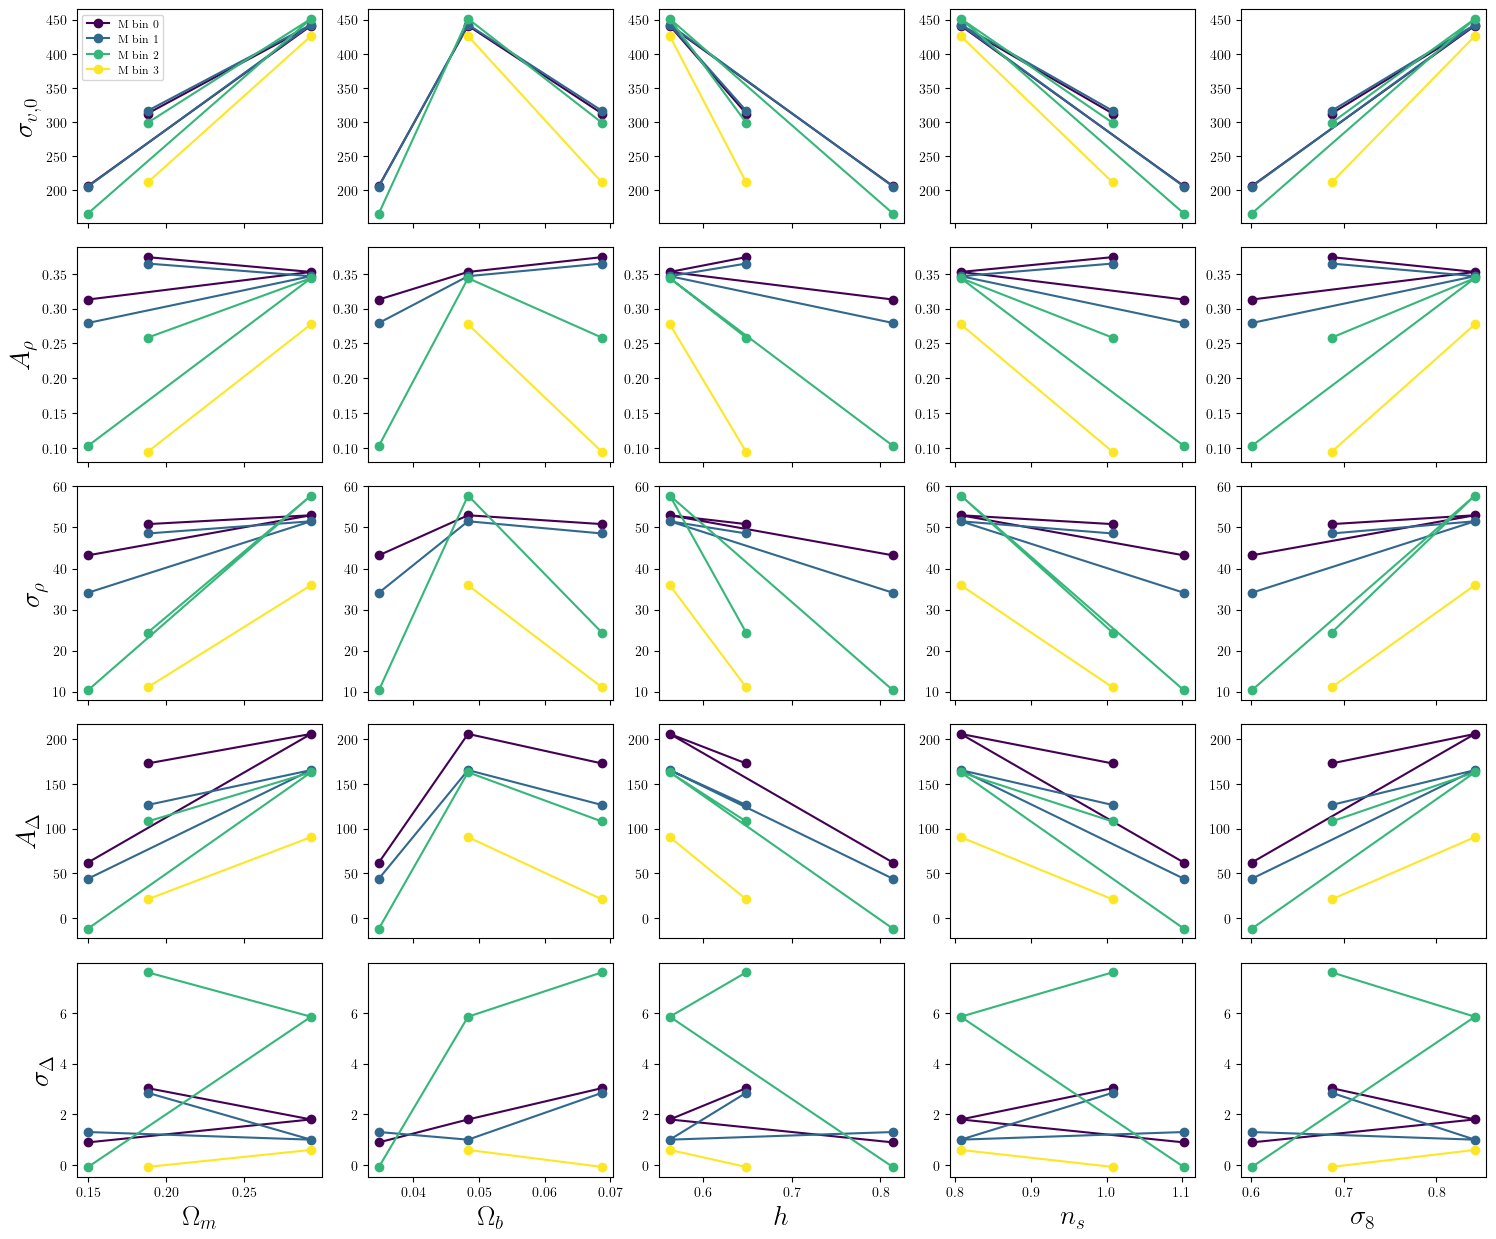

In [143]:
n_sims, n_masses, n_params = parameters.shape   # (3, 4, 5)
n_cosmo = LH_cosmos.shape[1]

# TODO: replace with your actual parameter/cosmology names
# labels = [f'sigma_v_{i}' for i in range(sig_opts.shape[-1])] + \
#                [f'Delta_{i}' for i in range(del_opts.shape[-1])]
# c_labels = [f'cosmo_{i}' for i in range(n_cosmo)]

colors = plt.cm.viridis(np.linspace(0, 1, n_masses))

fig, axes = plt.subplots(n_params, n_cosmo, figsize=(3*n_cosmo, 2.5*n_params), sharex='col')

for row in range(n_params):
    for col in range(n_cosmo):
        ax = axes[row, col]
        for m in range(n_masses):
            ax.plot(
                LH_cosmos[:n_sims, col],
                parameters[:, m, row],
                color=colors[m],
                label=f'M bin {m}' if (row == 0 and col == 0) else None, 
                marker='o',
            )
        if row == n_params - 1:
            ax.set_xlabel(c_labels[col])
        if col == 0:
            ax.set_ylabel(labels[row])

axes[0, 0].legend(fontsize=8)
plt.tight_layout()
plt.show()